# Week 6 Assignment: Autoencoder for Image Denoising

## Objective
Build deep learning autoencoder models that remove noise from MNIST images.

This notebook is adapted from the supplied GitHub reference notebook. It keeps the original three architectures:
- Fully Connected Autoencoder (FFNN)
- Transpose-Convolutional Autoencoder
- Upsampling-Convolutional Autoencoder

The key denoising change is:
**Noisy MNIST image → Autoencoder → Clean MNIST image**

The models are trained using noisy images as inputs and the original clean images as targets.


## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
import torch.optim as optim

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.11.0+cpu
CUDA available: False


## 2. Load and Normalize MNIST

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))


100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]

Training samples: 60000
Test samples: 10000


## 3. Create Train, Validation and Test DataLoaders

In [3]:
valid_size = 0.2
batch_size = 128
num_workers = 0

train_length = len(train_data)
indices = list(range(train_length))
np.random.seed(42)
np.random.shuffle(indices)

split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(
    train_data, batch_size=batch_size, sampler=train_sampler,
    num_workers=num_workers
)
valid_loader = DataLoader(
    train_data, batch_size=batch_size, sampler=valid_sampler,
    num_workers=num_workers
)
test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False,
    num_workers=num_workers
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Test batches:", len(test_loader))


Train batches: 375
Validation batches: 94
Test batches: 79


## 4. Add Noise to MNIST Images

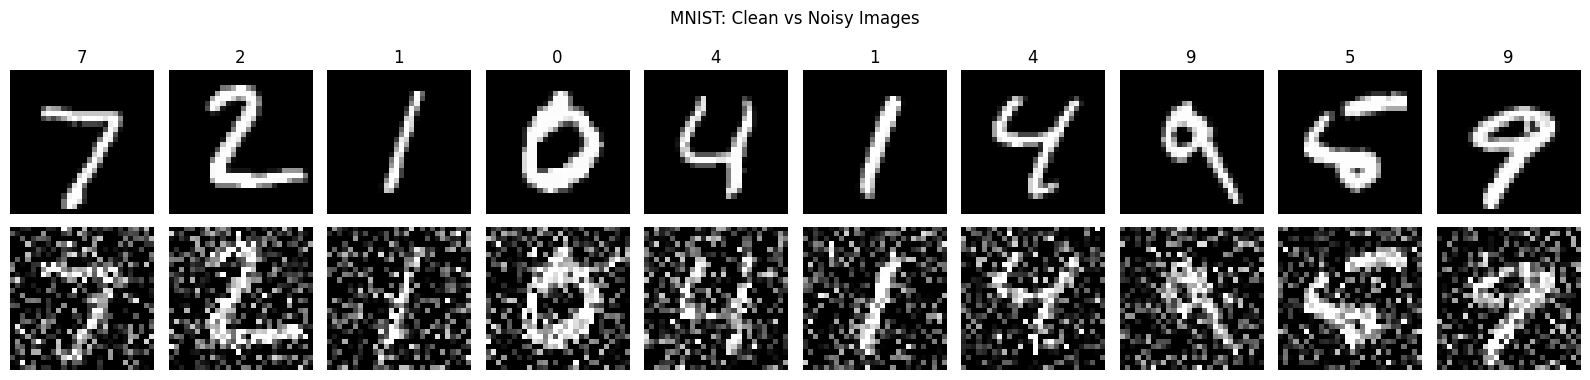

In [4]:
# Gaussian noise is added to the input images.
# The clean images remain the reconstruction targets.

NOISE_FACTOR = 0.40

def add_noise(images, noise_factor=NOISE_FACTOR):
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

# Visualize clean and noisy examples
images, labels = next(iter(test_loader))
noisy_images = add_noise(images)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for i in range(10):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].set_title(str(labels[i].item()))
    axes[0, i].axis("off")

    axes[1, i].imshow(noisy_images[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Clean", fontsize=12)
axes[1, 0].set_ylabel("Noisy", fontsize=12)
plt.suptitle("MNIST: Clean vs Noisy Images")
plt.tight_layout()
plt.show()


## 5. Define the Autoencoder Architectures

The architectures below follow the supplied GitHub reference, with the training objective changed for denoising.

In [5]:
class F_Auto_MNIST(nn.Module):
    def __init__(self, en_dim=32):
        super().__init__()
        self.encoder = nn.Linear(784, en_dim)
        self.decoder = nn.Linear(en_dim, 784)

    def forward(self, x):
        x = F.relu(self.encoder(x))
        x = torch.sigmoid(self.decoder(x))
        return x


class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.ConvTranspose2d(4, 16, 2, stride=2)
        self.de_conv2 = nn.ConvTranspose2d(16, 1, 2, stride=2)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.relu(self.de_conv1(x))
        x = torch.sigmoid(self.de_conv2(x))
        return x


class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.en_conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.en_conv2 = nn.Conv2d(16, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.de_conv1 = nn.Conv2d(4, 16, 3, padding=1)
        self.de_conv2 = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.en_conv1(x)))
        x = self.pool(F.relu(self.en_conv2(x)))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = F.relu(self.de_conv1(x))
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.sigmoid(self.de_conv2(x))
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1 = F_Auto_MNIST(32).to(device)
model_2 = Tran_conv_Auto_MNIST().to(device)
model_3 = upsamp_conv_Auto_MNIST().to(device)

print("Using device:", device)
print("FFNN parameters:", sum(p.numel() for p in model_1.parameters() if p.requires_grad))
print("Transpose CNN parameters:", sum(p.numel() for p in model_2.parameters() if p.requires_grad))
print("Upsampled CNN parameters:", sum(p.numel() for p in model_3.parameters() if p.requires_grad))


Using device: cpu
FFNN parameters: 50992
Transpose CNN parameters: 1077
Upsampled CNN parameters: 1477


## 6. Loss Function

In [6]:
criterion = nn.MSELoss()


## 7. Train and Validate the Denoising Autoencoders

**Important:** the model receives a noisy image, while the loss is calculated against the original clean image.

In [7]:
def trainNet(model, lr=0.001, state="fully", epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_keeper = {"train": [], "valid": []}
    valid_loss_min = np.inf

    for epoch in range(epochs):
        train_loss = 0.0
        valid_loss = 0.0

        model.train()
        for clean_images, _ in train_loader:
            clean_images = clean_images.to(device)
            noisy_images = add_noise(clean_images)

            if state == "fully":
                noisy_input = noisy_images.view(noisy_images.size(0), -1)
                clean_target = clean_images.view(clean_images.size(0), -1)
            else:
                noisy_input = noisy_images
                clean_target = clean_images

            optimizer.zero_grad()
            output = model(noisy_input)
            loss = criterion(output, clean_target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * clean_images.size(0)

        model.eval()
        with torch.no_grad():
            for clean_images, _ in valid_loader:
                clean_images = clean_images.to(device)
                noisy_images = add_noise(clean_images)

                if state == "fully":
                    noisy_input = noisy_images.view(noisy_images.size(0), -1)
                    clean_target = clean_images.view(clean_images.size(0), -1)
                else:
                    noisy_input = noisy_images
                    clean_target = clean_images

                output = model(noisy_input)
                loss = criterion(output, clean_target)
                valid_loss += loss.item() * clean_images.size(0)

        train_loss /= len(train_idx)
        valid_loss /= len(valid_idx)

        loss_keeper["train"].append(train_loss)
        loss_keeper["valid"].append(valid_loss)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Validation Loss: {valid_loss:.6f}"
        )

        if valid_loss < valid_loss_min:
            valid_loss_min = valid_loss

    return loss_keeper


## 8. Train the Three Models

In [8]:
EPOCHS = 10
LEARNING_RATE = 0.001

print("Training FFNN Autoencoder")
m1_loss = trainNet(model_1, LEARNING_RATE, "fully", EPOCHS)

print("\nTraining Transpose CNN Autoencoder")
m2_loss = trainNet(model_2, LEARNING_RATE, "conv", EPOCHS)

print("\nTraining Upsampled CNN Autoencoder")
m3_loss = trainNet(model_3, LEARNING_RATE, "conv", EPOCHS)


Training FFNN Autoencoder
Epoch 01/10 | Train Loss: 0.072331 | Validation Loss: 0.048584
Epoch 02/10 | Train Loss: 0.041342 | Validation Loss: 0.036506
Epoch 03/10 | Train Loss: 0.034280 | Validation Loss: 0.032448
Epoch 04/10 | Train Loss: 0.031523 | Validation Loss: 0.030731
Epoch 05/10 | Train Loss: 0.030306 | Validation Loss: 0.029915
Epoch 06/10 | Train Loss: 0.029726 | Validation Loss: 0.029666
Epoch 07/10 | Train Loss: 0.029444 | Validation Loss: 0.029293
Epoch 08/10 | Train Loss: 0.029257 | Validation Loss: 0.029159
Epoch 09/10 | Train Loss: 0.029091 | Validation Loss: 0.028975
Epoch 10/10 | Train Loss: 0.028980 | Validation Loss: 0.028897

Training Transpose CNN Autoencoder
Epoch 01/10 | Train Loss: 0.109313 | Validation Loss: 0.045991
Epoch 02/10 | Train Loss: 0.035151 | Validation Loss: 0.025998
Epoch 03/10 | Train Loss: 0.024571 | Validation Loss: 0.023750
Epoch 04/10 | Train Loss: 0.023192 | Validation Loss: 0.022719
Epoch 05/10 | Train Loss: 0.022419 | Validation Loss: 0.

## 9. Plot Training and Validation Loss

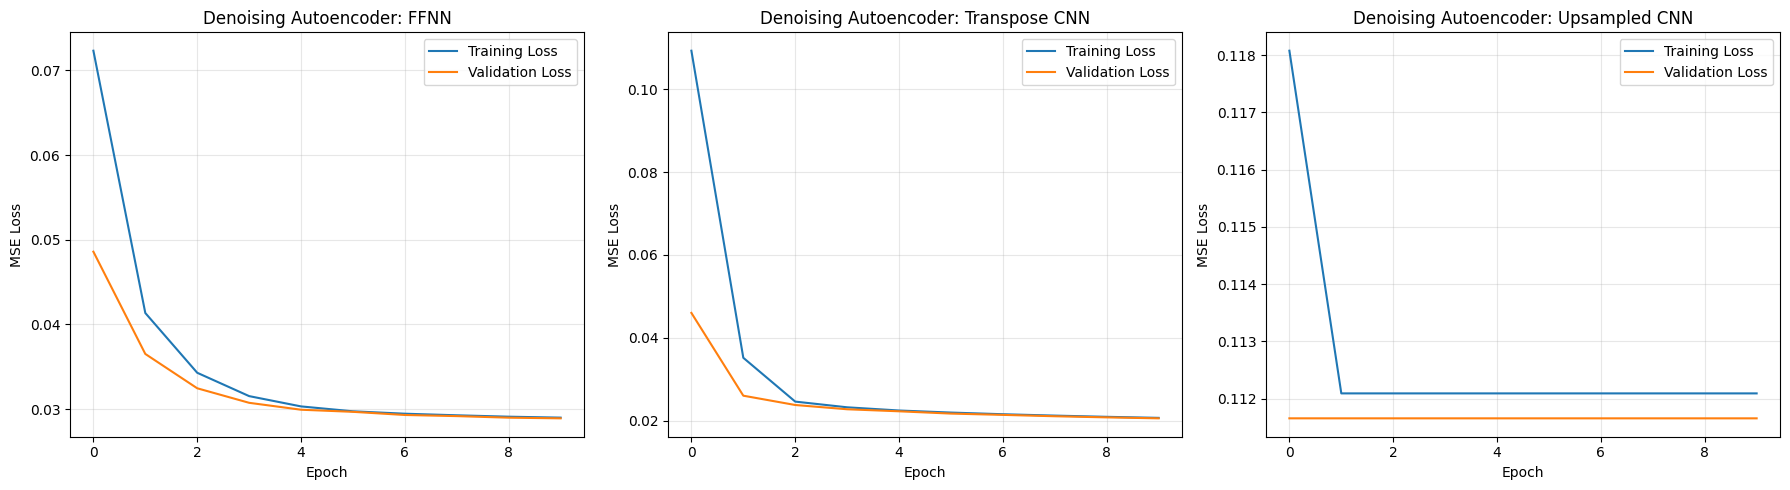

In [9]:
titles = ["FFNN", "Transpose CNN", "Upsampled CNN"]
model_losses = [m1_loss, m2_loss, m3_loss]

fig = plt.figure(figsize=(18, 5))

for idx, losses in enumerate(model_losses, start=1):
    ax = fig.add_subplot(1, 3, idx)
    ax.plot(losses["train"], label="Training Loss")
    ax.plot(losses["valid"], label="Validation Loss")
    ax.set_title("Denoising Autoencoder: " + titles[idx-1])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Quantitative Test Evaluation

In [10]:
def evaluate_model(model, state="fully"):
    model.eval()
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for clean_images, _ in test_loader:
            clean_images = clean_images.to(device)
            noisy_images = add_noise(clean_images)

            if state == "fully":
                noisy_input = noisy_images.view(noisy_images.size(0), -1)
                clean_target = clean_images.view(clean_images.size(0), -1)
            else:
                noisy_input = noisy_images
                clean_target = clean_images

            output = model(noisy_input)
            batch_loss = criterion(output, clean_target)

            total_loss += batch_loss.item() * clean_images.size(0)
            total_count += clean_images.size(0)

    return total_loss / total_count


ffnn_test_mse = evaluate_model(model_1, "fully")
transpose_test_mse = evaluate_model(model_2, "conv")
upsample_test_mse = evaluate_model(model_3, "conv")

results = {
    "FFNN": ffnn_test_mse,
    "Transpose CNN": transpose_test_mse,
    "Upsampled CNN": upsample_test_mse
}

print("Test reconstruction MSE:")
for name, mse in results.items():
    print(f"{name}: {mse:.6f}")


Test reconstruction MSE:
FFNN: 0.028493
Transpose CNN: 0.020206
Upsampled CNN: 0.113958


## 11. Compare Noisy, Denoised and Original Images

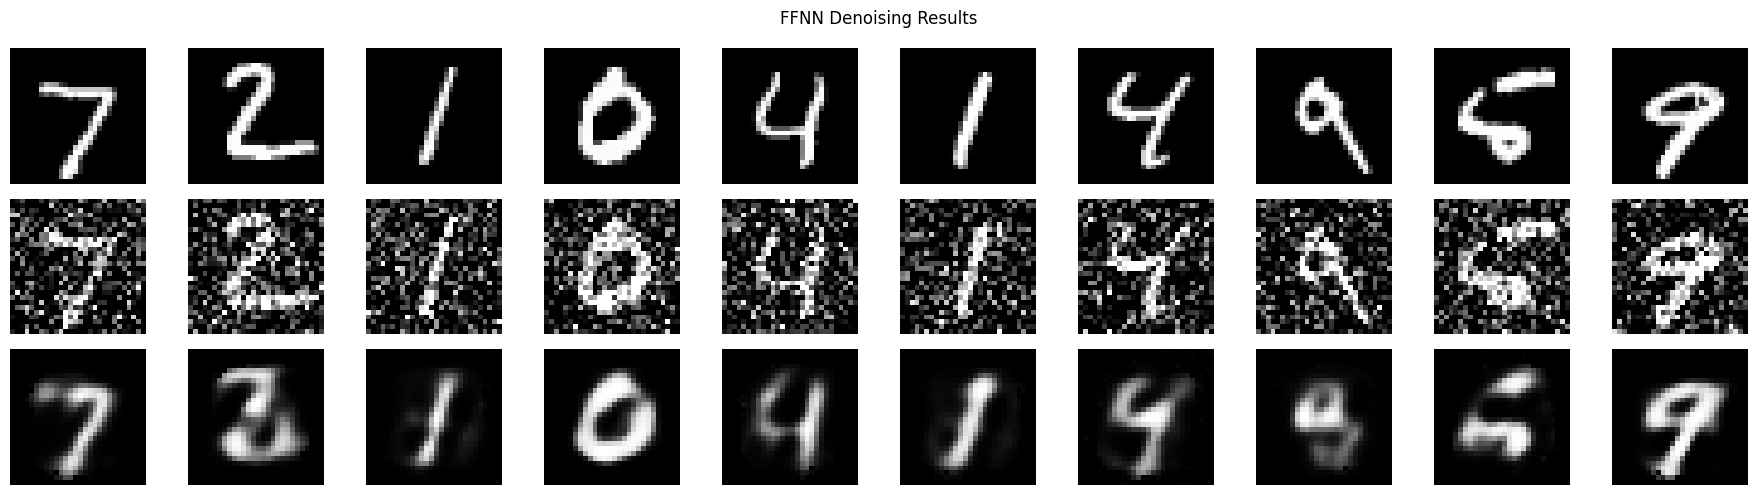

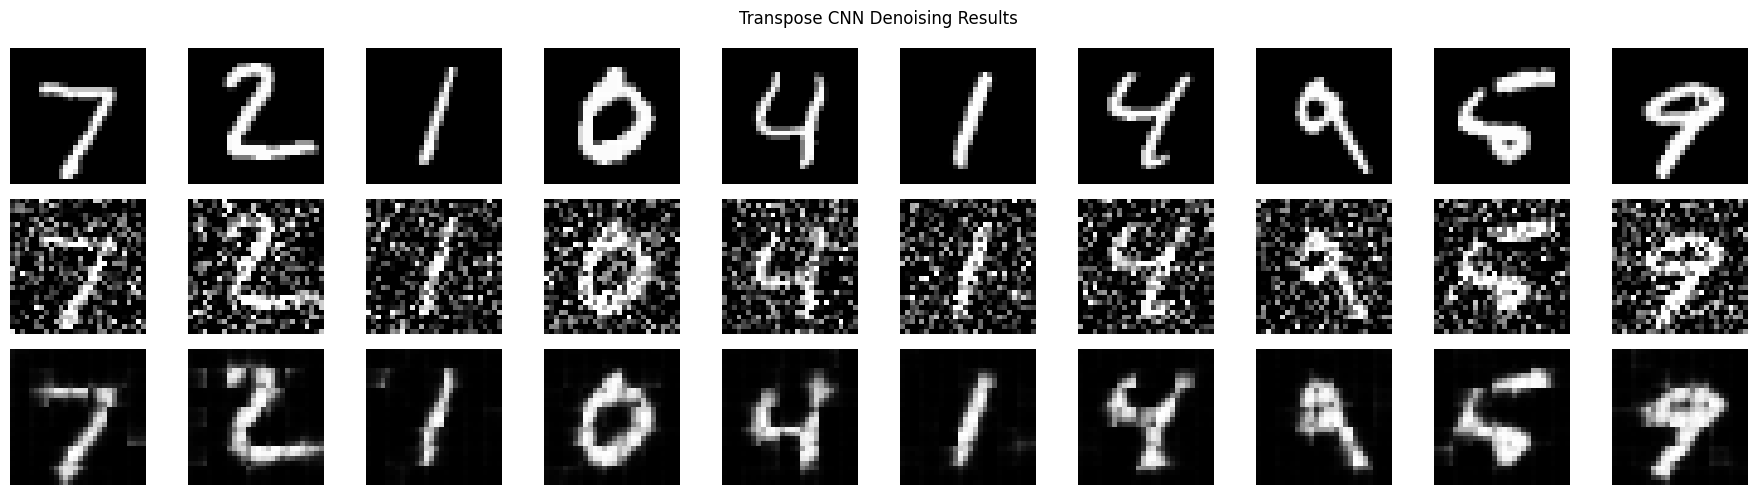

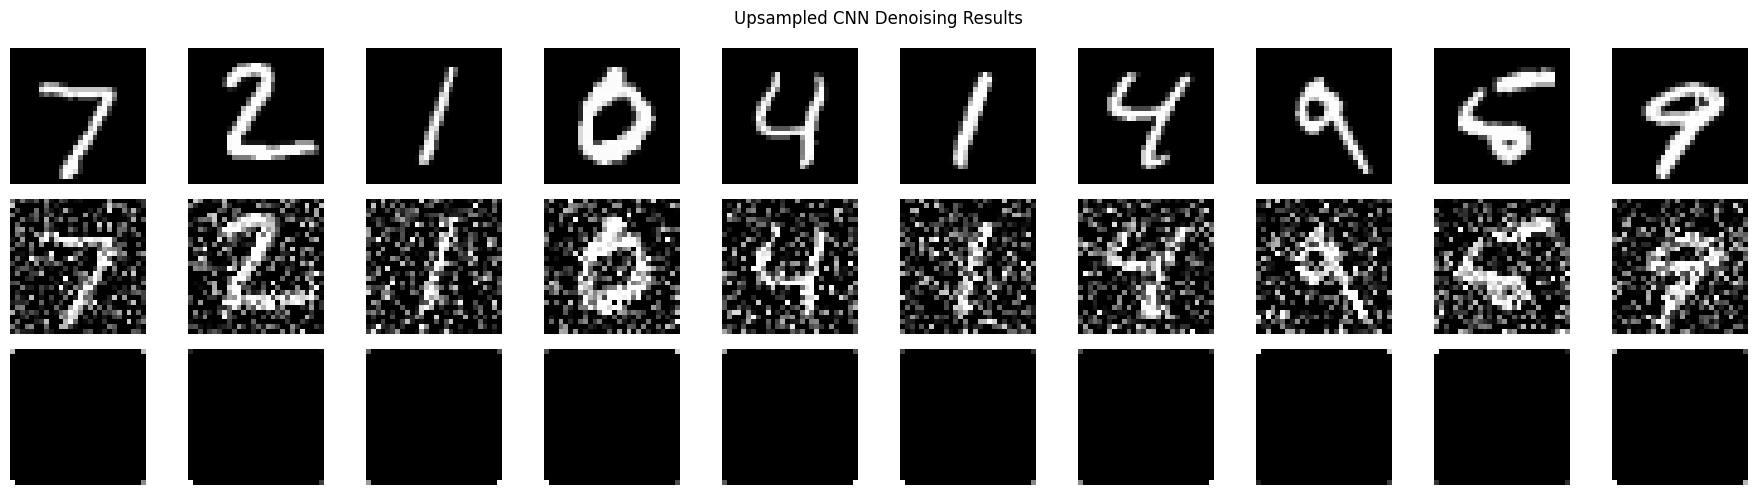

In [11]:
def show_denoising_results(model, state="fully", title="Model"):
    model.eval()

    clean_images, labels = next(iter(test_loader))
    noisy_images = add_noise(clean_images)

    with torch.no_grad():
        clean_device = clean_images.to(device)
        noisy_device = noisy_images.to(device)

        if state == "fully":
            model_input = noisy_device.view(noisy_device.size(0), -1)
        else:
            model_input = noisy_device

        output = model(model_input)

    if state == "fully":
        output = output.view(-1, 1, 28, 28)

    output = output.cpu().numpy()
    noisy_images = noisy_images.numpy()
    clean_images = clean_images.numpy()

    fig, axes = plt.subplots(3, 10, figsize=(18, 5))

    for i in range(10):
        axes[0, i].imshow(clean_images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(noisy_images[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")

        axes[2, i].imshow(output[i].squeeze(), cmap="gray")
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Noisy", fontsize=11)
    axes[2, 0].set_ylabel("Denoised", fontsize=11)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_denoising_results(model_1, "fully", "FFNN Denoising Results")
show_denoising_results(model_2, "conv", "Transpose CNN Denoising Results")
show_denoising_results(model_3, "conv", "Upsampled CNN Denoising Results")


## 12. Final Comparison

The comparison uses test reconstruction MSE. Lower MSE means the reconstructed image is closer to the clean target.


In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["FFNN", "Transpose CNN", "Upsampled CNN"],
    "Test MSE": [ffnn_test_mse, transpose_test_mse, upsample_test_mse],
    "Parameters": [
        sum(p.numel() for p in model_1.parameters() if p.requires_grad),
        sum(p.numel() for p in model_2.parameters() if p.requires_grad),
        sum(p.numel() for p in model_3.parameters() if p.requires_grad)
    ]
})

comparison = comparison.sort_values("Test MSE").reset_index(drop=True)
comparison


,Model,Test MSE,Parameters
0,Transpose CNN,0.020206,1077
1,FFNN,0.028493,50992
2,Upsampled CNN,0.113958,1477


## 13. Interpretation and Conclusion

The denoising autoencoder was trained using **noisy MNIST images as inputs and clean MNIST images as reconstruction targets**.

### Architecture comparison
- The **FFNN autoencoder** treats the image as a flattened 784-dimensional vector and therefore does not explicitly preserve 2D spatial structure.
- The **Transpose CNN autoencoder** uses convolutional feature extraction followed by transposed convolutions to reconstruct the image.
- The **Upsampled CNN autoencoder** uses convolutional feature extraction followed by upsampling and convolution.

### Training objective
Mean Squared Error (MSE) is used because the task is image reconstruction. The model is rewarded for producing pixel values close to the clean target image.

### Final conclusion
The denoising experiment demonstrates how an autoencoder can learn to remove Gaussian noise from MNIST images. The final comparison table and the Original/Noisy/Denoised visualizations provide both quantitative and qualitative evidence of denoising performance.

The model with the lowest test MSE should be considered the best-performing architecture for this particular run. Exact results depend on the random noise and training run.


## 14. Viva / Discussion Questions

### 1. What is an autoencoder?
An autoencoder is a neural network that learns to compress data into a smaller representation and then reconstruct the original input from it.

### 2. What is the difference between a standard autoencoder and a denoising autoencoder?
A standard autoencoder reconstructs the same input it receives. A denoising autoencoder takes a noisy input and learns to reconstruct the clean original image.

### 3. Why are noisy images used as inputs while clean images are used as targets?
This teaches the model to learn the meaningful features of the original image while ignoring the added noise.

### 4. Why is MSE suitable for image reconstruction?
MSE measures the pixel-wise difference between the reconstructed and original images. Lower MSE means the reconstruction is closer to the clean image.

### 5. What is the role of the encoder?
The encoder compresses the input image into a smaller latent representation while retaining its most important features.

### 6. What is the role of the decoder?
The decoder takes the latent representation and reconstructs it back into an image similar to the original clean image.

### 7. Why can CNN-based autoencoders be better suited to images than fully connected autoencoders?
CNNs preserve spatial relationships between nearby pixels and efficiently learn visual features. Fully connected networks flatten the image and lose this spatial structure.

### 8. What is the purpose of adding Gaussian noise?
Gaussian noise creates corrupted training inputs so the autoencoder learns to remove noise and recover the clean image.

### 9. What happens if the noise factor is increased?
The input becomes more corrupted, making denoising harder. If the noise is too high, important image information may also be lost.

### 10. What is the difference between transposed convolution and upsampling?
Transposed convolution learns filters to increase spatial dimensions. Upsampling directly increases the dimensions using methods such as nearest-neighbor interpolation, followed by convolution.
